# **Finding Duplicates Lab**

## Introduction

Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 

## Objectives

In this lab, you will perform the following:

1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.

Import pandas module

In [1]:
import pandas as pd

Import matplotlib

In [2]:
import matplotlib.pyplot as plt

## **Load the dataset into a dataframe**

<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>

In [3]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:

Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:

In [4]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

## Identify and Analyze Duplicates

### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.

In [5]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Display first few duplicate rows
print(df[df.duplicated()].head())

Number of duplicate rows: 0
Empty DataFrame
Columns: [ResponseId, MainBranch, Age, Employment, RemoteWork, Check, CodingActivities, EdLevel, LearnCode, LearnCodeOnline, TechDoc, YearsCode, YearsCodePro, DevType, OrgSize, PurchaseInfluence, BuyNewTool, BuildvsBuy, TechEndorse, Country, Currency, CompTotal, LanguageHaveWorkedWith, LanguageWantToWorkWith, LanguageAdmired, DatabaseHaveWorkedWith, DatabaseWantToWorkWith, DatabaseAdmired, PlatformHaveWorkedWith, PlatformWantToWorkWith, PlatformAdmired, WebframeHaveWorkedWith, WebframeWantToWorkWith, WebframeAdmired, EmbeddedHaveWorkedWith, EmbeddedWantToWorkWith, EmbeddedAdmired, MiscTechHaveWorkedWith, MiscTechWantToWorkWith, MiscTechAdmired, ToolsTechHaveWorkedWith, ToolsTechWantToWorkWith, ToolsTechAdmired, NEWCollabToolsHaveWorkedWith, NEWCollabToolsWantToWorkWith, NEWCollabToolsAdmired, OpSysPersonal use, OpSysProfessional use, OfficeStackAsyncHaveWorkedWith, OfficeStackAsyncWantToWorkWith, OfficeStackAsyncAdmired, OfficeStackSyncHaveWo

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.

In [6]:
# Find duplicate response patterns based on selected columns
pattern_duplicates = df[df.duplicated(
    subset=['MainBranch', 'Employment', 'RemoteWork'],
    keep=False
)]

# Display sample duplicate response patterns
print(pattern_duplicates[['MainBranch', 'Employment', 'RemoteWork']].head())

# Clarification
print("\nThese are not necessarily duplicate records.")
print("They represent multiple respondents giving identical answers for these columns.\n")

# Check which other columns frequently share identical values
shared_values = pattern_duplicates.nunique()

print("Number of unique values in each column within duplicate-pattern groups:")
print(shared_values)

                       MainBranch           Employment RemoteWork
0  I am a developer by profession  Employed, full-time     Remote
1  I am a developer by profession  Employed, full-time     Remote
2  I am a developer by profession  Employed, full-time     Remote
3           I am learning to code   Student, full-time        NaN
4  I am a developer by profession   Student, full-time        NaN

These are not necessarily duplicate records.
They represent multiple respondents giving identical answers for these columns.

Number of unique values in each column within duplicate-pattern groups:
ResponseId             65270
MainBranch                 5
Age                        8
Employment                72
RemoteWork                 3
                       ...  
JobSatPoints_11           79
SurveyLength               3
SurveyEase                 3
ConvertedCompYearly     6109
JobSat                    11
Length: 114, dtype: int64


### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.

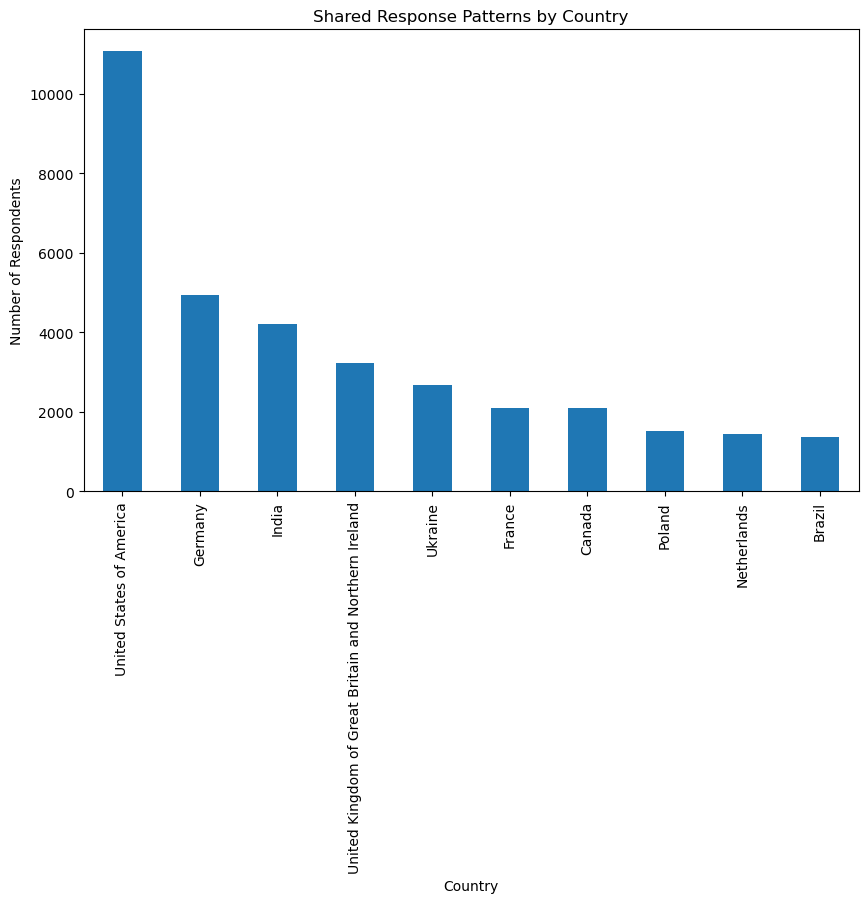

In [7]:
import matplotlib.pyplot as plt

# Group duplicate response patterns by Country
country_distribution = pattern_duplicates['Country'].value_counts().head(10)

# Bar chart for Country distribution
plt.figure(figsize=(10,6))
country_distribution.plot(kind='bar')

plt.title('Shared Response Patterns by Country')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')

plt.show()

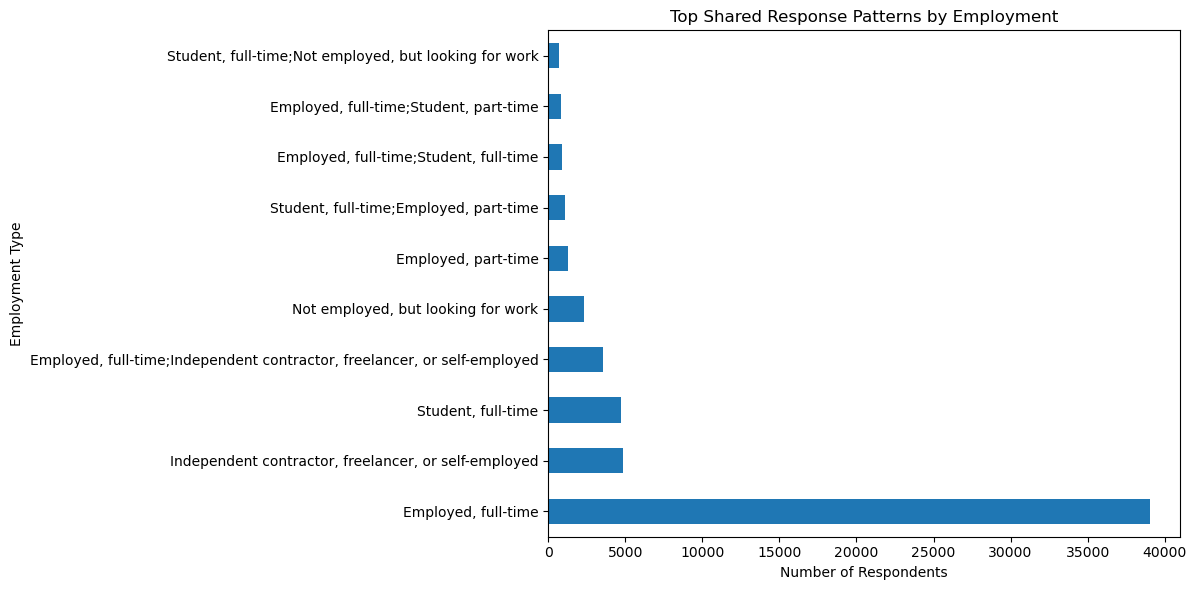

In [9]:
# Group duplicate response patterns by Employment
employment_distribution = (
    pattern_duplicates['Employment']
    .value_counts()
    .head(10)   # show top 10 categories only
)

plt.figure(figsize=(12,6))

employment_distribution.plot(kind='barh')

plt.title('Top Shared Response Patterns by Employment')
plt.xlabel('Number of Respondents')
plt.ylabel('Employment Type')

plt.tight_layout()
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.

In [10]:
# Check columns that may define uniqueness
print(df.columns)

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)


In [11]:
# Check uniqueness of possible identifier columns
print("Unique Respondent IDs:", df['ResponseId'].nunique())
print("Total Rows:", len(df))

Unique Respondent IDs: 65437
Total Rows: 65437


In [12]:
# Check duplicates based on selected survey-response columns
subset_duplicates = df.duplicated(
    subset=['MainBranch', 'Employment', 'RemoteWork']
).sum()

print("Duplicates based on selected columns:", subset_duplicates)

Duplicates based on selected columns: 64876


## The dataset represents survey responses from multiple individuals.

Columns such as MainBranch, Employment, and RemoteWork
cannot define record uniqueness because many respondents
can legitimately share the same answers.

A unique identifier column such as ResponseId is more
appropriate for identifying unique records.

Therefore, removing rows based only on a subset of columns
is not recommended, because it may incorrectly remove
valid responses from different participants.

Only complete duplicate rows or duplicate ResponseId values
should generally be considered for removal.

## Verify and Document Duplicate Removal Process

### Task 5: Documentation
1. Document the process of identifying and removing duplicates.

## Documentation of Duplicate Removal Process

1. Duplicate rows were identified using the duplicated() function.

2. The duplicate records were reviewed to confirm that they
   were exact copies of existing rows.

3. Exact duplicate rows were removed using drop_duplicates().

4. Duplicate responses based on selected survey columns
   were not removed because different respondents may
   legitimately provide identical answers.

5. ResponseId was considered the appropriate column for
   determining record uniqueness in the survey dataset.

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.

## Reasoning for Selecting Columns in Duplicate Detection

- Complete row comparison was used to identify true duplicate records,
  because all column values must match for a row to be considered
  an exact duplicate.

- Columns such as MainBranch, Employment, and RemoteWork were not
  sufficient for defining uniqueness because many respondents can
  legitimately share the same answers.

- Survey datasets often contain repeated response patterns that
  represent different individuals rather than duplicated records.

- A unique identifier column such as ResponseId is more appropriate
  for determining record uniqueness.

- Therefore, duplicates were removed only when entire rows matched,
  avoiding accidental deletion of valid survey responses.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.